In [77]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import tabpfn_client
from tabpfn_client import TabPFNClassifier
import seaborn as sns
import pandas as pd
from dotenv import load_dotenv
import os
from sklearn.preprocessing import MinMaxScaler

load_dotenv()

True

In [78]:
model_id = 'Prior-Labs/tabpfn'

In [79]:
df = pd.read_csv('../data/model_ready.csv')

df.head()

,date,close,previous_day_close,previous_day_high,previous_day_low,previous_day_open,previous_day_volume,1_day_max,1_day_min,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,previous_day_numerical_sentiment,previous_day_mean_sentiment_probability,previous_day_percent_positive,previous_day_percent_negative,previous_day_percent_neutral
0,2026-01-28,668.73,672.97,676.8150,664.6600,674.59,13148719.0,677.6775,666.1000,677.6775,661.2855,677.6775,661.2855,3,0.158879,0.790941,0.299065,0.140187,0.560748
1,2026-01-29,738.31,668.73,677.6775,666.1000,674.50,25709600.0,744.0000,712.5500,744.0000,664.6600,744.0000,661.2855,4,0.170543,0.801010,0.302326,0.131783,0.565891
2,2026-01-30,716.50,738.31,744.0000,712.5500,737.43,59852903.0,732.1700,713.5900,744.0000,666.1000,744.0000,661.2855,5,-0.027027,0.806134,0.209459,0.236486,0.554054
3,2026-02-02,706.41,716.50,732.1700,713.5900,727.50,23744573.0,721.3000,703.5201,721.3000,703.5201,744.0000,703.5201,1,-0.109375,0.837781,0.156250,0.265625,0.578125
4,2026-02-03,691.70,706.41,721.3000,703.5201,714.60,14365224.0,717.0000,686.4100,721.3000,686.4100,732.1700,686.4100,2,-0.076923,0.814024,0.153846,0.230769,0.615385


In [80]:
def get_price_status(row):
    if row['close'] > row['previous_day_close']:
        return 1 # Increased
    elif row['close'] < row['previous_day_close']:
        return -1 # Decreased
    else:
        return 0 # No Change

df['price_status'] = df.apply(get_price_status, axis=1)
df = df.drop(columns=['close',
                      'previous_day_close']) # Remove close price columns
df = df.set_index('date')

df.head()

,previous_day_high,previous_day_low,previous_day_open,previous_day_volume,1_day_max,1_day_min,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,previous_day_numerical_sentiment,previous_day_mean_sentiment_probability,previous_day_percent_positive,previous_day_percent_negative,previous_day_percent_neutral,price_status
date,,,,,,,,,,,,,,,,,
2026-01-28,676.8150,664.6600,674.59,13148719.0,677.6775,666.1000,677.6775,661.2855,677.6775,661.2855,3,0.158879,0.790941,0.299065,0.140187,0.560748,-1
2026-01-29,677.6775,666.1000,674.50,25709600.0,744.0000,712.5500,744.0000,664.6600,744.0000,661.2855,4,0.170543,0.801010,0.302326,0.131783,0.565891,1
2026-01-30,744.0000,712.5500,737.43,59852903.0,732.1700,713.5900,744.0000,666.1000,744.0000,661.2855,5,-0.027027,0.806134,0.209459,0.236486,0.554054,-1
2026-02-02,732.1700,713.5900,727.50,23744573.0,721.3000,703.5201,721.3000,703.5201,744.0000,703.5201,1,-0.109375,0.837781,0.156250,0.265625,0.578125,-1
2026-02-03,721.3000,703.5201,714.60,14365224.0,717.0000,686.4100,721.3000,686.4100,732.1700,686.4100,2,-0.076923,0.814024,0.153846,0.230769,0.615385,-1


In [81]:
X = df.iloc[:, :-1]
Y = df[['price_status']]

X.shape, Y.shape

((71, 16), (71, 1))

In [82]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=42)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((35, 16), (35, 1), (36, 16), (36, 1))

In [83]:
X_scalar = MinMaxScaler()

X_train_as_numpy = X_scalar.fit_transform(X_train)
X_test_as_numpy = X_scalar.transform(X_test)

Y_train_as_numpy = Y_train.to_numpy()
Y_test_as_numpy = Y_test.to_numpy()

X_train_as_numpy.shape, X_test_as_numpy.shape, Y_train_as_numpy.shape, Y_test_as_numpy.shape

((35, 16), (36, 16), (35, 1), (36, 1))

In [84]:
X_train_as_numpy = X_train_as_numpy.reshape((-1, 16))
Y_train_as_numpy = Y_train_as_numpy.reshape((-1,))

X_test_as_numpy = X_test_as_numpy.reshape((-1, 16))
Y_test_as_numpy = Y_test_as_numpy.reshape((-1,))

X_train_as_numpy.shape, X_test_as_numpy.shape, Y_train_as_numpy.shape, Y_test_as_numpy.shape

((35, 16), (36, 16), (35,), (36,))

In [85]:
api_token = os.getenv('tabpfn_token')
tabpfn_client.set_access_token(api_token)

classifier = TabPFNClassifier()
classifier.fit(X_train_as_numpy, Y_train_as_numpy, )

00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '1f2b06f4da59409aa5c7bb8dee9b0424'}))

In [86]:
test_preds = classifier.predict(X_test_as_numpy)
train_preds =  classifier.predict(X_train_as_numpy)

00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:00 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:00 Predicting... Done!


<Axes: >

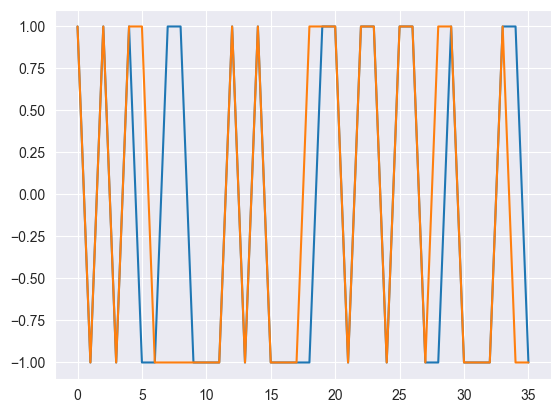

In [87]:
sns.lineplot(test_preds)
sns.lineplot(Y_test_as_numpy)

In [88]:
# Using a Smaller Train Size improved Test Accuracy

print("Test Accuracy:", f1_score(Y_test_as_numpy, test_preds))
print("Train Accuracy:", f1_score(Y_train_as_numpy, train_preds))

Test Accuracy: 0.8125
Train Accuracy: 0.975609756097561
